In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

## Contents

1. [Problem formulation](#1-problem-formulation)
2. [Data sources](#2-data-sources)
3. [Mathematical background](#3-mathematical-background)
4. [Pre-registered hypotheses and tests](#4-pre-registered-hypotheses-and-tests)
5. [Exploratory analysis](#5-exploratory-analysis)
6. [Discussion](#6-discussion)
7. [Reproducibility](#7-reproducibility)
8. [References](#8-references)

## 1. Problem formulation

### 1.1. What is Volcano Rush

Volcano Rush is a semi-cooperative strategy board game for 6-8 players. The group is stranded on a volcanic island and must complete missions to gather resources and build a boat before the volcano erupts; that shared escape is the cooperative layer. On top of it, players also compete individually for the most mission-success points. The game is asymmetric: every character has different abilities, and some have entirely different mechanics. This asymmetry is what makes it challenging to balance, and it is the problem this notebook investigates.

- Full rules: [`docs/game_rules.md`](../../docs/game_rules.md)
- Characters: [`docs/characters.md`](../../docs/characters.md)
- Missions: [`docs/missions.md`](../../docs/missions.md)
- Volcano cards: [`docs/volcano_cards.md`](../../docs/volcano_cards.md)
- Complication cards: [`docs/complication_cards.md`](../../docs/complication_cards.md)

### 1.2. Research question

The notebook investigates a single overarching question:

> Is *Volcano Rush* balanced across its three supported player counts (6, 7, 8) and its six character roles, and how does its design position it within the landscape of real cooperative board games on BoardGameGeek?

Character presence cannot be tested directly in this simulation, because the game rules force every character into every game (all six roles appear at 6 players; at 7 and 8 players the same six are present with one or two non-Craftsman roles duplicated at random). Character balance is therefore decomposed into two layers: whether *which* non-Craftsman is duplicated affects the team's win probability, and whether any character dominates the *personal scoring* layer. Combined with the player-count question and the cross-source comparison, this gives four narrower sub-questions:

1. Does the team's win probability depend on the player count?
2. At 7 and 8 players, does the team's win probability depend on which non-Craftsman role is duplicated?
3. Does any single character dominate personal scoring across all player counts?
4. How does Volcano Rush's design position it within the landscape of well-rated cooperative games on BoardGameGeek?

Sub-questions 1-3 become one pre-registered hypothesis each; the BGG cross-source question fans out into three (rating differences by cooperative sub-genre and by group size, plus a comparison of the simulation-optimal player count against the community-voted best count), for six pre-registered hypotheses in total. The full list lives in [`docs/hypotheses.md`](../../docs/hypotheses.md) and is tested in Section 4.

### 1.3. Why this matters

Game balance is a core design problem in any asymmetric strategy game. If one strategy always wins, the game becomes predictable and the replay value collapses; if one character has a structural advantage, the game feels unfair; if the set of mechanics and abilities is too narrow, experienced players quickly converge on a single optimal playstyle. For casual party games this is often acceptable, but strategy games are judged on the depth and fairness of their decision space.

*Volcano Rush* adds a less common twist: the group shares the win condition (escape the island before the volcano erupts), but one player is still crowned the scoring winner at the end. This semi-cooperative mix is unusual in the Bulgarian tabletop market the author is familiar with, and it makes balance a two-layered problem. A balanced Volcano Rush therefore needs:

1. Similar team win rates across the three supported player counts.
2. No single character dominating the personal scoring.
3. A design that sits sensibly within the landscape of well-rated cooperative games on BoardGameGeek - particularly on the player-count axis, where simulation and community data overlap.

These three conditions are what Section 4 operationalizes into testable hypotheses.

### 1.4. Prior work

There is a small but useful literature on board-game balance and on simulating tabletop play that frames the choices made here.

- **Balance as a design problem.** Schell (2009) [1] catalogues the recurring axes designers tune: starting-position fairness, dominance of strategies, and the cost-to-benefit ratio of game objects. The three balance conditions in 1.3 are a direct restatement of his framing for the specific case of an asymmetric semi-cooperative game.
- **Monte Carlo simulation for board games.** Chaslot et al. (2008) [2] popularized Monte Carlo Tree Search for game AI; the methodological lineage of "run many simulated games and read the empirical distribution" runs through that paper into modern AlphaZero-style work. The simulation engine used here is far simpler (rule-based agents, no tree search), but the validity argument is the same: with enough independent rollouts the empirical win rate converges to the true win rate by the law of large numbers.
- **Agent-based modelling of tabletop play.** Dubois, Barreteau, & Souchère (2013) [3] use agent-based simulation to study how role-playing-game settings shape participant attitudes; that paper is the closest published methodology to "use rule-based agents to study how a game's rules behave in aggregate". Its caveat - simulation captures rule mechanics, not social dynamics - is taken up here in Section 6's limitations.
- **External validity from community data.** Treating BoardGameGeek as an empirical population for cooperative-game design questions is informal but common in the design community. This project formalizes the comparison by filtering BGG to "well-rated cooperative games" via `NumUserRatings >= 500` and treating Volcano Rush's simulated profile as a single point in that empirical distribution (Hypotheses 4-6).

### 1.5. Scope and assumptions

**What the simulation models.** The simulation engine follows the rules documented in [`docs/game_rules.md`](../../docs/game_rules.md) exactly. Each player is replaced by a rule-based agent driven by hand-coded heuristics:

- Each character has a preferred mission type. For example, the Fire Starter prefers fire missions because its ability is strongest there; the Sailor prefers boat missions.
- Agents see the current scores of the other players. When they detect a scoring leader, with probability 75% they deprioritize that player during participant selection, introducing a mild competitive pressure against the leader.
- Agents have limited lookahead: they do not plan more than one round ahead and do not model the volcano deck beyond its visible card count.

**What the simulation does not model.** The simulation cannot reproduce any aspect of real-world play that depends on human-to-human interaction. In particular, it excludes:

- Table talk and in-game negotiation.
- House rules or ad-hoc rule interpretations.
- Social dynamics such as dominant or reluctant players, alliances, or grudges.
- Learning effects across sessions: every simulated game starts from a fresh agent state.

These omissions are limitations to keep in mind throughout the notebook. Conclusions drawn from the simulation apply to the rule-based-agent setting, and their transfer to real playtest sessions should itself be treated as a hypothesis, not a given.

## 2. Data sources

Two independent sources are used. They are loaded and described here; no inference is done in this section.

In [2]:
repository_path = pathlib.Path.cwd().parents[1]
simulations_path = repository_path / "data" / "simulations"
bgg_path = repository_path / "data" / "bgg"
hypothesis_results_path = repository_path / "data" / "hypothesis_results"

### 2.1. Source 1: Monte Carlo simulation

Generated by [`simulation_engine/`](../../simulation_engine) and exported to [`data/simulations/`](../../data/simulations). Run metadata is recorded in [`data/simulations/manifest.json`](../../data/simulations/manifest.json).

**Sampling plan**

- 4,000 games per player count (6, 7, 8), for a total of 12,000 games.
- Base seed: `20260428`. The same base seed is used across all three player-count scenarios; the per-game seed is `base_seed + game_index`, so every game is individually reproducible.

**Relationship to the Math Concepts project.** The simulation engine itself is the same version used in the Math Concepts phase of the project, but the random seed and sample size are different: the Math Concepts runs used `BASE_SEED = 1` with 1,000 games per player count, while this export uses `BASE_SEED = 20260428` with 4,000 games per count. Because the engine is deterministic given a seed, the two datasets share no individual games, and any pattern first observed in the Math Concepts work is therefore tested here on fresh, non-overlapping randomness.

**Files available**

- `games.csv`: one row per simulated game (game_id, seed, player count, outcome, rounds played, boat parts built and required, volcano cards remaining, a mission-failure counter).
- `game_characters.csv`: one row per (game, character) pair, with the character's final personal score and a copy of the game outcome for convenience.
- `game_resources.csv`: per-game resource usage (units consumed and mission failures caused by shortage), in long format over `WOOD`, `STONE`, `ROPE`.
- `game_tools.csv`: per-game tool state (repairs and failures while damaged), in long format over `KNIFE`, `VESSEL`.
- `character_contributions.csv`: per-character contribution breakdown (missions participated, boat missions participated, tools repaired, lesser-evil uses, requirement discounts used). **Win games only.**
- `manifest.json`: sampling plan, engine commit, and a full column-level schema for every table above.

In [3]:
simulation_games_data = pd.read_csv(simulations_path / "games.csv")

simulation_games_data.head()

,game_id,seed,player_count,outcome,rounds_played,boat_parts_built,boat_parts_required,volcano_cards_remaining,mission_failures_any_extra
0,296325ecc0d5ffe2,20260428,6,win,20,3,3,2,1
1,259a5d07d71f3473,20260429,6,win,20,3,3,1,0
2,74570438e9a72e0c,20260430,6,loss,13,2,3,0,0
3,6559fe61497155ac,20260431,6,win,15,3,3,4,0
4,5723fa7ec997a08b,20260432,6,loss,16,2,3,0,0


### 2.2. Source 2: BoardGameGeek

The second data source is the public **BoardGameGeek (BGG)** database, obtained from the Kaggle dataset *Board Games Database from BoardGameGeek* by threnjen ([kaggle page](https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek)). The original snapshot covers roughly 21,925 games across nine CSV tables; the local snapshot was downloaded on 2026-04-19. The upstream schema is documented verbatim in [`data/bgg/bgg_data_documentation.txt`](../../data/bgg/bgg_data_documentation.txt).

**Why this is a meaningful second source.** The simulation data answers how Volcano Rush behaves under its own rules. BGG answers how real cooperative games, as experienced by tens of thousands of players, sit on the rating and player-count axes. Treating Volcano Rush's simulated profile as a single point in BGG's empirical distribution lets the BGG comparison in Section 4 ask whether the game is typical or an outlier among well-rated co-op games, using a sample that has nothing to do with the simulation itself.

**Files used in hypothesis tests.** Only the two tables actually consumed by the per-hypothesis notebooks are committed under [`data/bgg/`](../../data/bgg); the other seven tables in the original Kaggle export (themes, subcategories, ratings distributions, user ratings, artists, designers, publishers) are not used in this project.

- `games.csv` (21,925 rows): one row per BGG game. The columns that matter for this project are `BayesAvgRating` (community rating, used in Hypotheses 4 and 5), `MaxPlayers` (player-count partition for Hypotheses 5 and 6), `BestPlayers` (community-voted modal best count, used in Hypothesis 6), and `NumUserRatings` (sample-reliability filter at >= 500).
- `mechanics.csv` (21,925 rows): one row per game, with a binary indicator column per mechanic. Two columns are directly relevant: `Cooperative Game` and `Semi-Cooperative Game`. Both are used to filter the population down to cooperative-flavoured games when forming the comparison group for Hypotheses 4, 5, and 6.

**On the `NumUserRatings >= 500` threshold.** 500 is a conventional cutoff in BGG-rating analyses rather than a derived bound. BGG's `BayesAvgRating` shrinks each game's rating toward a global prior near 5.5 with substantial weight, so games with very few user ratings sit close to the prior regardless of their true quality. Requiring at least 500 ratings excludes that prior-dominated tail while still leaving 4,710 games (about 22% of the snapshot) - enough for the cooperative subgroups in Hypotheses 4-6 to be analysed, with the caveat that the semi-cooperative subgroup ends up small (only 24 games), which costs Hypothesis 4 statistical power. Hypothesis 6 separately pre-registers a `>= 200` fallback for *its* large-group filter; Hypothesis 4 does not, so the 24-game limitation is just absorbed in the discussion.

In [4]:
bgg_games_data = pd.read_csv(bgg_path / "games.csv")

bgg_games_data.head()

,BGGId,Name,Description,YearPublished,GameWeight,AvgRating,BayesAvgRating,StdDev,MinPlayers,MaxPlayers,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
0,1,Die Macher,die macher game seven sequential political rac...,1986,4.3206,7.61428,7.10363,1.57979,3,5,...,21926,21926,0,1,0,0,0,0,0,0
1,2,Dragonmaster,dragonmaster tricktaking card game base old ga...,1981,1.9630,6.64537,5.78447,1.45440,3,4,...,21926,21926,0,1,0,0,0,0,0,0
2,3,Samurai,samurai set medieval japan player compete gain...,1998,2.4859,7.45601,7.23994,1.18227,2,4,...,21926,21926,0,1,0,0,0,0,0,0
3,4,Tal der Könige,triangular box luxurious large block tal der k...,1992,2.6667,6.60006,5.67954,1.23129,2,4,...,21926,21926,0,0,0,0,0,0,0,0
4,5,Acquire,acquire player strategically invest business t...,1964,2.5031,7.33861,7.14189,1.33583,2,6,...,21926,21926,0,1,0,0,0,0,0,0


### 2.3. Descriptive overview

Before any inference, a quick descriptive look at both data sources to orient the reader on shape, sanity-check the row counts, and surface obvious patterns. No tests here.

In [5]:
simulation_games_per_count = simulation_games_data.groupby("player_count").size()
simulation_outcome_counts = simulation_games_data["outcome"].value_counts()

print("Simulation:")
print(f"  total games:    {len(simulation_games_data):>6}")
print(f"  player counts:  {sorted(int(player_count) for player_count in simulation_games_data['player_count'].unique())}")
print(f"  per-count rows: {dict((int(k), int(v)) for k, v in simulation_games_per_count.items())}")
print(f"  outcomes:       {dict((k, int(v)) for k, v in simulation_outcome_counts.items())}")

print()
print("BGG:")
print(f"  total games:                {len(bgg_games_data):>6}")
print(f"  with NumUserRatings >= 500: {(bgg_games_data['NumUserRatings'] >= 500).sum()}")

Simulation:
  total games:     12000
  player counts:  [6, 7, 8]
  per-count rows: {6: 4000, 7: 4000, 8: 4000}
  outcomes:       {'loss': 6313, 'win': 5687}

BGG:
  total games:                 21925
  with NumUserRatings >= 500: 4710


**Win rate per player count.** Orientation chart for Hypothesis 1.

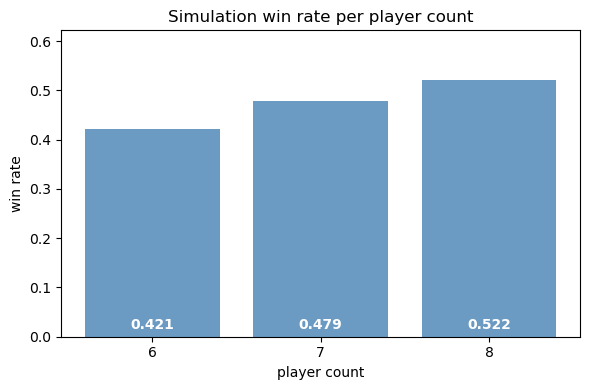

In [6]:
win_rate_per_count = (
    simulation_games_data.assign(is_win = simulation_games_data["outcome"].eq("win"))
    .groupby("player_count")["is_win"].mean()
)

plt.figure(figsize = (6, 4))

plt.bar(win_rate_per_count.index, win_rate_per_count.values, color = "steelblue", alpha = 0.8)

plt.xticks(win_rate_per_count.index)
plt.xlabel("player count")
plt.ylabel("win rate")
plt.ylim(0, win_rate_per_count.max() + 0.10)
plt.title("Simulation win rate per player count")

for player_count, win_rate in win_rate_per_count.items():
    plt.text(player_count, 0.01, f"{win_rate:.3f}",
             ha = "center", va = "bottom", color = "white", fontweight = "bold", fontsize = 10)
plt.tight_layout()

plt.show()

**BGG `BayesAvgRating` distribution.** Orientation chart for Hypotheses 4 and 5. The full BGG population has a long left tail (many old games stuck near the prior) and a concentrated peak around 5.5-6.5; the per-hypothesis filter `NumUserRatings >= 500` shifts the population rightward toward better-known games.

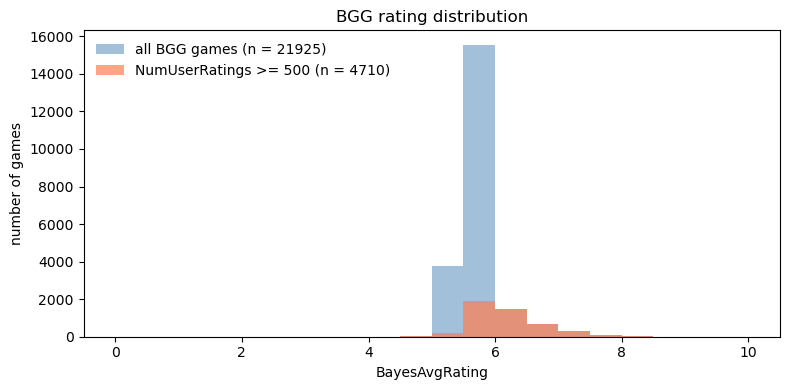

In [7]:
all_ratings = bgg_games_data["BayesAvgRating"]
filtered_ratings = bgg_games_data.loc[bgg_games_data["NumUserRatings"] >= 500, "BayesAvgRating"]

plt.figure(figsize = (8, 4))

bin_edges = [edge / 10 for edge in range(0, 101, 5)]

plt.hist(all_ratings, bins = bin_edges, color = "steelblue", alpha = 0.5,
         label = f"all BGG games (n = {len(all_ratings)})")
plt.hist(filtered_ratings, bins = bin_edges, color = "coral", alpha = 0.7,
         label = f"NumUserRatings >= 500 (n = {len(filtered_ratings)})")

plt.xlabel("BayesAvgRating")
plt.ylabel("number of games")
plt.title("BGG rating distribution")
plt.legend(frameon = False)
plt.tight_layout()

plt.show()

## 3. Mathematical background

This section explains the statistical tools used in Section 4 in plain language, so the reader does not have to take any formula on faith. Each per-hypothesis notebook applies one or more of these tools.

### 3.1. Confidence intervals

A 95% confidence interval (CI) is a range of plausible values for an unknown population quantity (a mean, a proportion). The correct reading is *not* "the true value is inside with 95% probability"; it is "if we repeated the same study many times, 95% of the CIs we would build this way would contain the true value". Two intervals are used here:

- **Wilson interval** for proportions (e.g. win rates). The standard interval for a binomial proportion; stays well-behaved even when the proportion is close to 0 or 1. Preferred over the simpler Wald interval, which collapses to a point at $\hat{p} = 0$ or $\hat{p} = 1$ and under-covers near either boundary for small $n$.
- **Student-t interval** for means (e.g. mean BayesAvgRating). It uses the t-distribution to widen the interval when the sample is small; with hundreds of observations it is essentially the normal interval.

Two CIs that do *not* overlap imply the underlying populations differ at the 5% level - a useful visual shortcut when the per-group CIs are plotted.

### 3.2. Hypothesis testing

A hypothesis test compares observed data to a null hypothesis ($H_0$) that says "the effect we are looking for is zero / no different / no association". The test produces a **p-value**: the probability of seeing data at least this extreme if $H_0$ were true. If the p-value is below the significance level $\alpha = 0.05$, we **reject** $H_0$ in favour of the alternative $H_1$. The notebook never says "accept $H_0$" or "prove" anything; failing to reject means the data did not provide enough evidence against $H_0$.

The tests used:

- **Chi-square goodness-of-fit / independence.** For categorical data (e.g. wins vs losses across player counts, or win/loss across duplicated-role buckets). Asks whether observed counts match expected counts under $H_0$.
- **One-way ANOVA (F-test).** For comparing more than two means (e.g. final score across six characters). The central limit theorem makes the F-test's normality assumption irrelevant once each group has hundreds of observations.
- **Welch's two-sample t-test.** For comparing two means with possibly different variances (e.g. semi-cooperative vs fully cooperative ratings). Preferred over the classical Student t-test because it does not assume equal variances and reduces to Student's when both samples have the same size and dispersion - so it is never worse and is strictly better when variances differ, which is the default assumption for the BGG comparisons here.
- **One-sample t-test.** For comparing one sample's mean to a fixed reference value (e.g. BGG mean BestPlayers vs VR's simulation-optimal count).
- **Mann-Whitney U-test.** Non-parametric: compares the rank distributions of two groups instead of their means. Used as a robustness check when one group is small enough that skew might mislead a t-test.

### 3.3. Multiple-testing correction

When several hypotheses are tested in the same family, the chance that *at least one* of them rejects $H_0$ purely by luck inflates with the number of tests. Holm-Bonferroni is the simplest control. Sort the $m$ p-values from smallest to largest, then for the $i$-th smallest compare it to $\alpha / (m - i + 1)$. Reject all hypotheses up to and including the first one whose p-value is *not* below its threshold; once a hypothesis fails to reject, all later ones automatically fail to reject as well. The procedure controls the family-wise error rate at $\alpha$.

The summary in Section 4 applies Holm-Bonferroni across the six pre-registered hypotheses with $\alpha = 0.05$.

## 4. Pre-registered hypotheses and tests

Each hypothesis from [`docs/hypotheses.md`](../../docs/hypotheses.md) is written up in its own notebook under [`hypotheses/`](hypotheses/), so each test can be run, reviewed, and iterated on in isolation. The Holm-Bonferroni correction across the six tests is applied here in Section 4.8 once each per-hypothesis notebook has been run.

* [Hypothesis 1 - Player-count balance](hypotheses/1_hypothesis_player_count_balance.ipynb)
* [Hypothesis 2 - Duplication effect at 7 and 8 players](hypotheses/2_hypothesis_duplication_effect.ipynb)
* [Hypothesis 3 - Character dominance in personal scoring](hypotheses/3_hypothesis_character_dominance.ipynb)
* [Hypothesis 4 - Semi-cooperative vs fully cooperative ratings on BGG](hypotheses/4_hypothesis_semicoop_vs_coop.ipynb)
* [Hypothesis 5 - Large-group vs smaller-group cooperative ratings on BGG](hypotheses/5_hypothesis_large_vs_small_group.ipynb)
* [Hypothesis 6 - Simulation-optimal player count vs BGG community sweet spot](hypotheses/6_hypothesis_optimal_player_count.ipynb)

### Summary of results

Each row records the test, the observed p-value, and the Holm-Bonferroni-corrected decision at $\alpha = 0.05$. Holm-Bonferroni is applied step-down: the $i$-th smallest p-value is compared to $\alpha / (m - i + 1)$ where $m = 6$, and once any hypothesis fails to reject, all later ones (with larger p-values) automatically fail too. The p-values are read from each per-hypothesis notebook's exported JSON file under [`data/hypothesis_results/`](../../data/hypothesis_results), so re-running any hypothesis notebook automatically refreshes this summary on the next execution.

In [ ]:
expected_hypothesis_count = 6
found_files = sorted(hypothesis_results_path.glob("h*.json")) if hypothesis_results_path.exists() else []
if len(found_files) != expected_hypothesis_count:
    raise FileNotFoundError(
        f"Expected {expected_hypothesis_count} hypothesis result files in "
        f"{hypothesis_results_path}, found {len(found_files)}. "
        f"Re-execute all per-hypothesis notebooks first - see Section 7 reproducibility."
    )

hypothesis_results = sorted(
    (json.loads(path.read_text()) for path in found_files),
    key = lambda result: result["hypothesis"],
)

alpha = 0.05
test_count = len(hypothesis_results)

sorted_by_p_value = sorted(hypothesis_results, key = lambda result: result["p_value"])

decisions_by_hypothesis = {}
already_failed = False
for index, result in enumerate(sorted_by_p_value):
    threshold = alpha / (test_count - index)
    rejects = (not already_failed) and (result["p_value"] < threshold)
    if not rejects:
        already_failed = True
    decisions_by_hypothesis[result["hypothesis"]] = (threshold, "reject H0" if rejects else "fail to reject H0")

summary_rows = [
    {
        "hypothesis": result["hypothesis"],
        "description": result["description"],
        "test": result["test"],
        "p_value": result["p_value"],
        "holm_threshold": decisions_by_hypothesis[result["hypothesis"]][0],
        "decision": decisions_by_hypothesis[result["hypothesis"]][1],
    }
    for result in hypothesis_results
]

summary = pd.DataFrame(summary_rows).set_index("hypothesis")
summary

## 5. Exploratory analysis

Patterns noticed while working through the per-hypothesis notebooks that were *not* pre-registered. Each of these would need a fresh pre-registered hypothesis to be confirmed properly; they are surfaced here as observations, not claims.

- **Builder is a two-faced character.** Hypothesis 2 found that *duplicating* Builder pushes the team win rate up (54.5% at 7 players, the only duplicated role with a measurable effect). Hypothesis 3 found that Builder's personal score (6.03 at 6 players) sits *below* the overall mean (6.16). Builder is "good for the team, mediocre for the player". The two findings together point at the wood discount as a team-cost reducer that the simulation's competitive participant-selection heuristic does not let Builder cash in for personal points.

- **Cook and Fire Starter dominate scoring without dominating wins.** Hypothesis 3 found Cook (6.55) and Fire Starter (6.42) measurably above the mean. Neither shows up in Hypothesis 2's duplication effect. The implication is that the imbalance lives in the per-mission point rewards on food / fire mission types, not in any team-level resource discount.

- **Most large-group co-op games on BGG have no community consensus on best player count.** In the Hypothesis 6 filter, 109 of 173 cooperative games supporting 6+ players have `BestPlayers = 0` (no community vote). That is a 63% no-consensus rate, which is itself a signal: large-group co-op is the kind of game whose ideal count varies by group enough that no single best-count vote dominates.

- **The two simulation-side imbalances affect different characters.** H2 says duplication-Builder; H3 says scoring-Cook/Fire Starter. From a design perspective, fixing one of the two would not automatically fix the other - they appear to come from different rule mechanics (resource discount vs per-mission scoring weights), each of which would need its own targeted change.

## 6. Discussion

### 6.1. What the evidence supports

After Holm-Bonferroni correction at $\alpha = 0.05$, **five of six pre-registered hypotheses are rejected**:

- **H1.** Win rate is not the same across player counts. The simulation gives 42.1% at 6 players, 47.9% at 7, and 52.2% at 8, with disjoint Wilson CIs. The 6-player configuration sits below the 50-65% design-target band; 7- and 8-player are inside it.
- **H2.** Win rate depends on which non-Craftsman role is duplicated at 7 and 8 players. Duplicating Builder lifts the win rate by about 8 percentage points; no other duplicated role produces a measurable shift.
- **H3.** Per-character expected final scores at 6 players differ. Cook and Fire Starter sit measurably above the overall mean; Builder, Gatherer, and Sailor sit below.
- **H5.** Among BGG cooperative games, the large-group bucket (`MaxPlayers >= 6`) rates ≈ 0.19 BayesAvgRating points lower than the smaller-group bucket on average.
- **H6.** The mean BGG community-voted `BestPlayers` for large-group co-op (3.53, with a 95% CI of [3.16, 3.90]) sits far below VR's simulation-optimal player count of 8.

The one **fail-to-reject** is **H4**: with only 24 semi-cooperative games in the BGG sample after the `NumUserRatings >= 500` filter, the comparison against fully cooperative games has insufficient power to detect a small-to-moderate effect. The point estimate (semi-coop ≈ 0.16 above fully coop) is consistent with both "no real difference" and a small effect either way.

### 6.2. Limitations

- **Agent-strategy assumptions.** Every simulated game uses the same hand-coded heuristics for mission selection, participant scoring, and shuffle decisions. Real groups vary, negotiate, and learn between sessions; none of that is in the simulation. Conclusions from H1, H2, H3 apply to the rule-based agent setting, not directly to real playtest sessions.
- **Simulation sample size.** 4,000 games per player count is large enough to detect effects of ≈ 3-5 percentage points in win rate; finer effects may be missed. Per-character scoring at 6 players has 4,000 observations per character, which is plenty.
- **BGG-side selection effects.** The `NumUserRatings >= 500` filter screens out games with too few ratings to trust the Bayesian rating. This biases the sample toward popular and older games; niche or recent large-group co-op titles are under-represented. H5 and H6 conclusions apply to the well-rated BGG population, not the full design space.
- **`BayesAvgRating` shrinkage compresses effect sizes.** Hypotheses 4 and 5 test `BayesAvgRating`, BGG's Bayesian-shrunk rating that pulls each game toward a global prior near 5.5 with substantial weight. For our filtered population both H5 group means sit around 7 on the raw `AvgRating` scale and get pulled down by ≈ 0.85 points each. The H5 group gap is 0.25 points on `AvgRating` but compresses to 0.19 on `BayesAvgRating` - direction and rejection are unchanged, but the reported effect size understates the difference users actually express. For H5 the rejection is robust regardless; for H4 (fail to reject) shrinkage could in principle mask a small effect, though the n=24 semi-cooperative subgroup is the dominant power constraint. `BayesAvgRating` is the BGG-canonical and pre-registered metric, but `AvgRating` would be a defensible alternative on grounds of effect-size fidelity.
- **Holm-Bonferroni scope.** The correction is applied across the six hypotheses pre-registered in `docs/hypotheses.md`. If the same data were used to test additional non-pre-registered hypotheses, the family-wise error rate would no longer be controlled.

### 6.3. Threats to validity

- **Confounding between player count and other rule mechanics.** H1 measures the marginal effect of player count on win rate, but the rules that change with player count (number of boat parts required, number of duplicated roles) also change with it. The win-rate-rises-with-count pattern could be driven by the per-participant cost model rather than by group size per se.
- **Model mis-specification on the agent side.** The competitive-pressure-against-leader heuristic (probability 75% deprioritization) is a guess; it shifts character scoring and could exaggerate or compress the H3 effect.
- **BGG data quality.** `BestPlayers` in the Kaggle export is already collapsed to a single integer; the parsing rule in the original pre-registration (handling ranges and comma-separated lists) is therefore moot for this snapshot but would matter for re-runs against a different export.

### 6.4. Future work

- **Stronger agents.** Replace the hand-coded heuristics with reinforcement-learning agents and re-run H1, H2, H3 to see whether the imbalances survive a more competent player model.
- **Larger BGG sample.** Re-run H4 on a relaxed `NumUserRatings >= 200` filter as a sensitivity analysis (without changing the headline pre-registered result).
- **Targeted re-balancing simulations.** Test the two design fixes implied by H2 and H3 (narrow Builder's wood discount; reweight food / fire mission scoring) and re-simulate to confirm the imbalances move in the intended direction.
- **Live playtest cross-check.** Use the simulation predictions as priors for a small live-playtest study (6, 7, 8 players, recorded win rate and personal scores). The BGG `BestPlayers` divergence in H6 specifically predicts that real groups may underperform the simulation's "8 is balanced" claim.

## 7. Reproducibility

- **Python environment.** Defined in [`environment.yml`](../../environment.yml) (Python 3.11, pandas, numpy, scipy, statsmodels, matplotlib).
- **Simulation seed and sample size.** `BASE_SEED = 20260428`, 4,000 games per player count (12,000 total). The per-game seed is `BASE_SEED + game_index`, so every game is individually reproducible.
- **Simulation outputs.** `data/simulations/` holds the CSV exports used by all per-hypothesis notebooks; the schema is documented in [`data/simulations/manifest.json`](../../data/simulations/manifest.json).
- **BGG snapshot.** Kaggle dataset *Board Games Database from BoardGameGeek* by threnjen, downloaded on 2026-04-19 to [`data/bgg/`](../../data/bgg). The upstream schema is in [`data/bgg/bgg_data_documentation.txt`](../../data/bgg/bgg_data_documentation.txt).
- **How to re-generate.**
    1. Re-run the simulation export: `python -m simulation_engine.export.run --base-seed 20260428 --n-games 4000 --output data/simulations/`
    2. Re-execute each per-hypothesis notebook top-to-bottom (`jupyter nbconvert --to notebook --execute notebooks/data_science/hypotheses/<file>.ipynb --output <file>.ipynb`). Each notebook writes its result to `data/hypothesis_results/h{n}.json`.
    3. Re-execute this notebook top-to-bottom; the Section 4 summary table loads p-values from `data/hypothesis_results/` automatically, so any updated per-hypothesis result flows through without manual editing.

## 8. References

**Data sources**

- BoardGameGeek dataset (Kaggle): https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek
- Simulation engine source: [`simulation_engine/`](../../simulation_engine) and [`data/simulations/manifest.json`](../../data/simulations/manifest.json)

**Internal documents**

- Pre-registration: [`docs/hypotheses.md`](../../docs/hypotheses.md)
- Game rules: [`docs/game_rules.md`](../../docs/game_rules.md)
- Characters, missions, complication and volcano cards: [`docs/characters.md`](../../docs/characters.md), [`docs/missions.md`](../../docs/missions.md), [`docs/complication_cards.md`](../../docs/complication_cards.md), [`docs/volcano_cards.md`](../../docs/volcano_cards.md)
- Math Concepts companion notebook: [`notebooks/math_concepts/board_game_simulation.ipynb`](../math_concepts/board_game_simulation.ipynb)

**Prior work (cited in Section 1.4)**

- [1] Schell, J. (2009). *Level 16: Game Balance.* Game Design Concepts. https://gamedesignconcepts.wordpress.com/2009/08/20/level-16-game-balance/
- [2] Chaslot, G., Bakkes, S., Szita, I., & Spronck, P. (2008). *Monte-Carlo Tree Search: A New Framework for Game AI.* AIIDE. https://ojs.aaai.org/index.php/AIIDE/article/view/18700
- [3] Dubois, E., Barreteau, O., & Souchère, V. (2013). *An Agent-Based Model to Explore Game Setting Effects on Attitude Change During a Role Playing Game Session.* Journal of Artificial Societies and Social Simulation, 16(1), 2. https://www.jasss.org/16/1/2.html